# Codveda Technology — Data Analytics Internship
## Level 1 (Basic) — Task 1 & Task 2
**Dataset :** `iris.csv` (150 observations, 4 variables numériques + 1 variable catégorielle `species`)

**Auteur :** Fortuné Assouan

---
Ce notebook couvre :
- **Task 1 — Data Cleaning and Preprocessing** : chargement, valeurs manquantes, doublons, formats incohérents.
- **Task 2 — Exploratory Data Analysis (EDA)** : statistiques descriptives, distributions, corrélations.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


---
# Task 1 : Data Cleaning and Preprocessing

**Objectifs**
1. Charger le dataset avec pandas.
2. Identifier et traiter les valeurs manquantes.
3. Supprimer les doublons et uniformiser les formats incohérents (texte, catégories).


## 1.1 Chargement du dataset

In [2]:
df = pd.read_csv("iris.csv")
print(f"Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()


Dimensions : 150 lignes, 5 colonnes


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1.2 Inspection de la structure

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
df.describe(include="all")


,sepal_length,sepal_width,petal_length,petal_width,species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 1.3 Valeurs manquantes
On vérifie systématiquement la présence de valeurs manquantes, même si le dataset semble propre au premier coup d'œil — c'est une étape obligatoire de tout pipeline de nettoyage.

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"valeurs_manquantes": missing, "pourcentage_%": missing_pct})
print(missing_report)

if missing.sum() == 0:
    print("\nAucune valeur manquante détectée sur ce dataset.")
else:
    # Stratégie de traitement (à adapter) : imputation par la médiane pour le numérique
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    print("\nValeurs manquantes numériques imputées par la médiane de chaque colonne.")


              valeurs_manquantes  pourcentage_%
sepal_length                   0            0.0
sepal_width                    0            0.0
petal_length                   0            0.0
petal_width                    0            0.0
species                        0            0.0

Aucune valeur manquante détectée sur ce dataset.


## 1.4 Doublons
On identifie puis on supprime les lignes strictement dupliquées.

In [6]:
n_duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées trouvées : {n_duplicates}")
df[df.duplicated(keep=False)].sort_values(list(df.columns))


Nombre de lignes dupliquées trouvées : 3


,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [7]:
df_before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
df_after = df.shape[0]
print(f"Lignes avant suppression : {df_before}")
print(f"Lignes après suppression : {df_after}")
print(f"Doublons supprimés : {df_before - df_after}")


Lignes avant suppression : 150
Lignes après suppression : 147
Doublons supprimés : 3


## 1.5 Standardisation des formats incohérents
On uniformise la colonne catégorielle `species` (casse, espaces superflus) et on vérifie la cohérence des types numériques — bonne pratique même quand la colonne semble déjà propre.

In [8]:
# Uniformisation du texte : minuscule + suppression des espaces superflus
df["species"] = df["species"].str.strip().str.lower()

print("Catégories uniques après nettoyage :", df["species"].unique().tolist())
print("\nTypes de colonnes :")
print(df.dtypes)


Catégories uniques après nettoyage : ['setosa', 'versicolor', 'virginica']

Types de colonnes :
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## 1.6 Dataset nettoyé — aperçu final

In [9]:
print(f"Dataset final : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df_clean = df.copy()
df_clean.to_csv("iris_clean.csv", index=False)
df_clean.head()


Dataset final : 147 lignes, 5 colonnes


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
# Task 2 : Exploratory Data Analysis (EDA)

**Objectifs**
1. Calculer les statistiques résumées (moyenne, médiane, mode, écart-type).
2. Visualiser les distributions (histogrammes, boxplots, scatter plots).
3. Identifier les corrélations entre variables numériques.


## 2.1 Statistiques descriptives

In [10]:
num_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

summary = pd.DataFrame({
    "mean": df_clean[num_cols].mean(),
    "median": df_clean[num_cols].median(),
    "mode": df_clean[num_cols].mode().iloc[0],
    "std": df_clean[num_cols].std(),
    "min": df_clean[num_cols].min(),
    "max": df_clean[num_cols].max(),
}).round(3)
summary


,mean,median,mode,std,min,max
sepal_length,5.856,5.8,5.0,0.829,4.3,7.9
sepal_width,3.056,3.0,3.0,0.437,2.0,4.4
petal_length,3.780,4.4,1.4,1.759,1.0,6.9
petal_width,1.209,1.3,0.2,0.758,0.1,2.5


### Statistiques par espèce

In [11]:
df_clean.groupby("species")[num_cols].agg(["mean", "median", "std"]).round(2)


sepal_length              sepal_width              petal_length  \
                   mean median   std        mean median   std         mean   
species                                                                      
setosa             5.01    5.0  0.36        3.43    3.4  0.38         1.46   
versicolor         5.94    5.9  0.52        2.77    2.8  0.31         4.26   
virginica          6.60    6.5  0.63        2.98    3.0  0.32         5.56   

                        petal_width               
           median   std        mean median   std  
species                                           
setosa       1.50  0.18        0.25    0.2  0.11  
versicolor   4.35  0.47        1.33    1.3  0.20  
virginica    5.60  0.55        2.03    2.0  0.28

## 2.2 Distributions — Histogrammes
Un histogramme par variable numérique, avec estimation de densité (KDE).

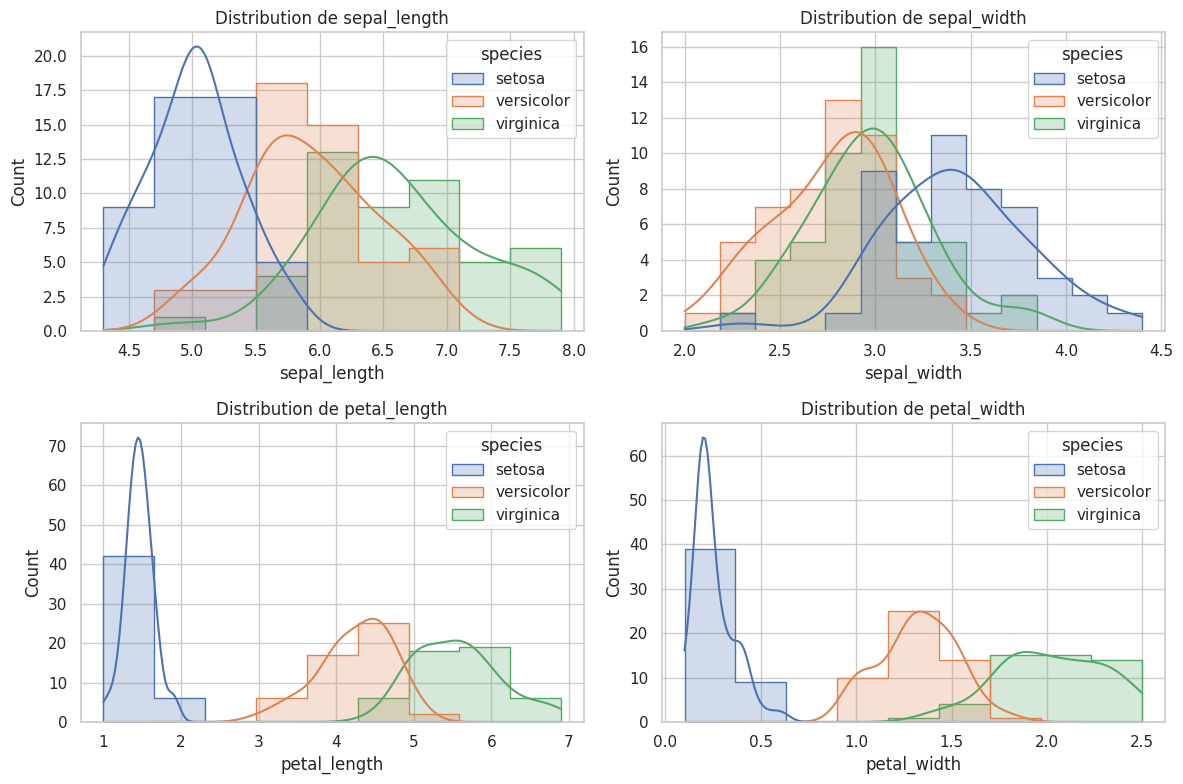

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(data=df_clean, x=col, hue="species", kde=True, ax=ax, element="step")
    ax.set_title(f"Distribution de {col}")
plt.tight_layout()
plt.savefig("fig_histograms.png", dpi=120)
plt.show()


## 2.3 Boxplots par espèce
Pour repérer la dispersion et les valeurs atypiques (outliers) par variable et par espèce.

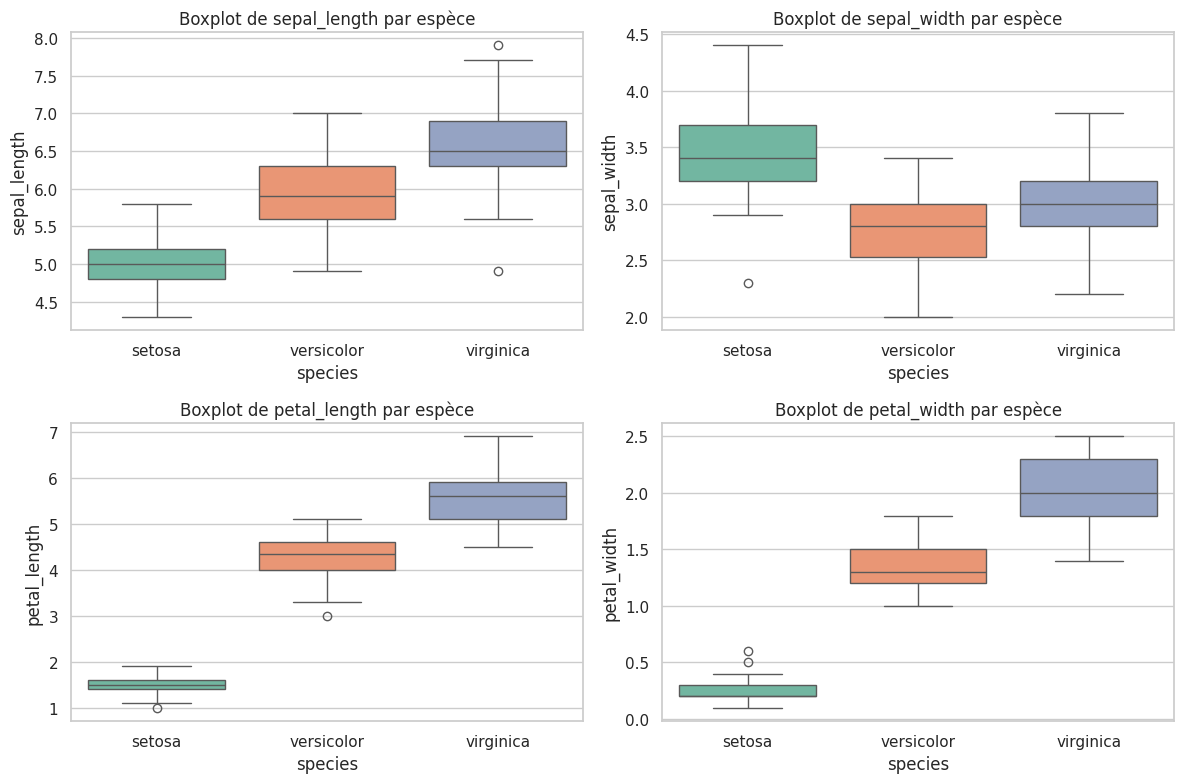

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df_clean, x="species", y=col, hue="species", palette="Set2", legend=False, ax=ax)
    ax.set_title(f"Boxplot de {col} par espèce")
plt.tight_layout()
plt.savefig("fig_boxplots.png", dpi=120)
plt.show()


## 2.4 Relations entre variables — Scatter plots
Les nuages de points par paire de variables permettent de voir comment les espèces se séparent visuellement.

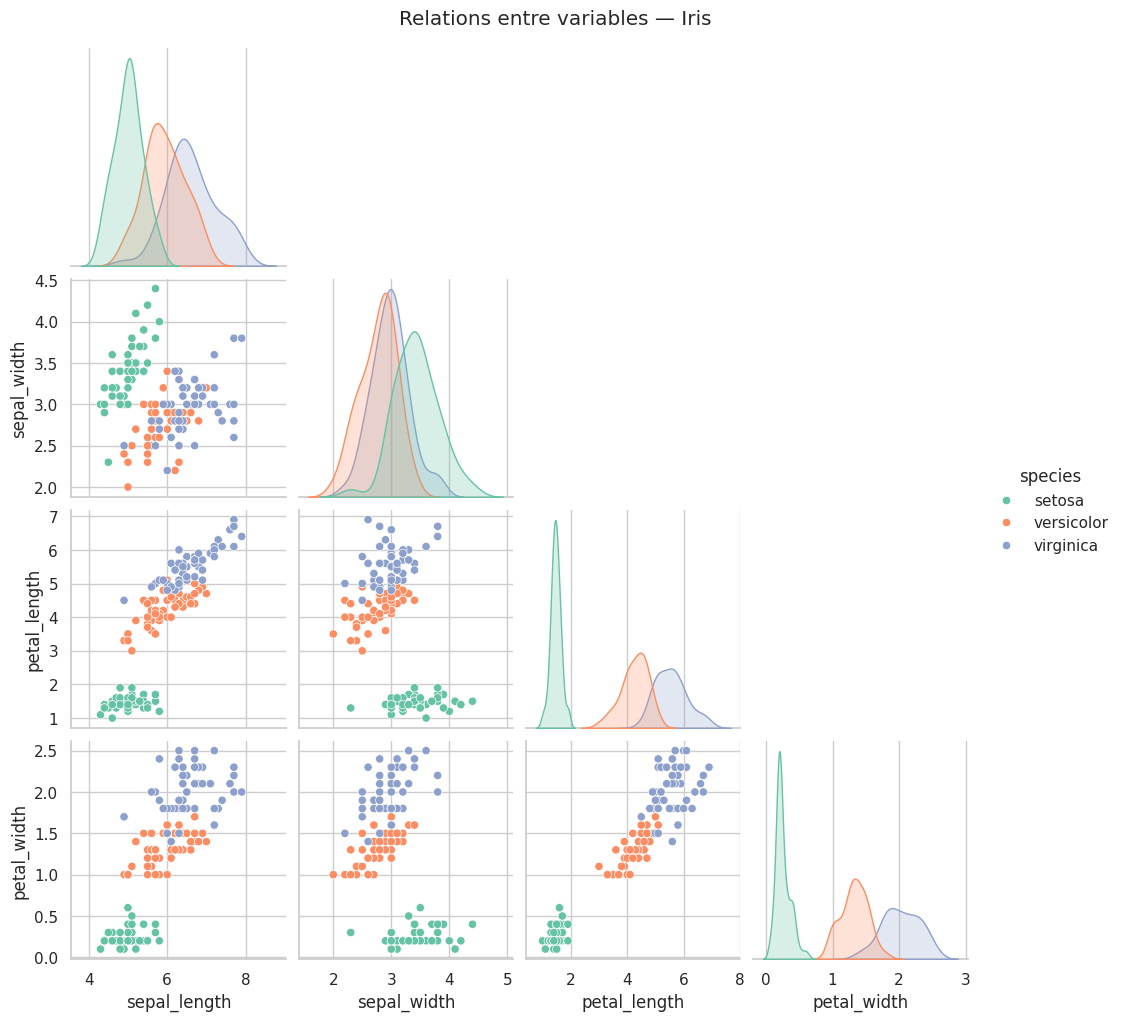

In [14]:
pairplot = sns.pairplot(df_clean, hue="species", diag_kind="kde", palette="Set2", corner=True)
pairplot.fig.suptitle("Relations entre variables — Iris", y=1.02)
pairplot.savefig("fig_pairplot.png", dpi=120)
plt.show()


## 2.5 Matrice de corrélation
Corrélation de Pearson entre les 4 variables numériques.

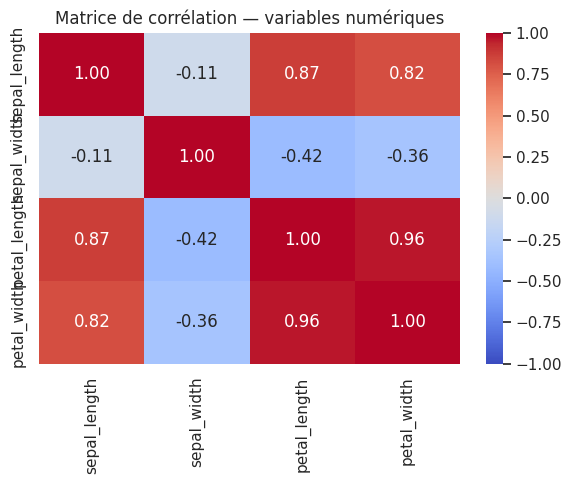

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.109321,0.871305,0.817058
sepal_width,-0.109321,1.000000,-0.421057,-0.356376
petal_length,0.871305,-0.421057,1.000000,0.961883
petal_width,0.817058,-0.356376,0.961883,1.000000


In [15]:
corr = df_clean[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Matrice de corrélation — variables numériques")
plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=120)
plt.show()

corr


## 2.6 Synthèse des insights (EDA)

- **Aucune valeur manquante** n'a été trouvée dans le dataset ; **3 lignes dupliquées** ont été identifiées et supprimées lors du nettoyage (Task 1).
- `petal_length` et `petal_width` sont **très fortement corrélées** (r proche de 0,96), ce qui en fait les deux variables les plus discriminantes entre espèces.
- `sepal_length` est également bien corrélée à `petal_length` et `petal_width`, tandis que `sepal_width` est la variable la moins corrélée aux autres.
- **Setosa** se distingue nettement des deux autres espèces sur `petal_length` et `petal_width` (aucun chevauchement de distribution) — elle serait donc trivialement séparable par un modèle de classification.
- **Versicolor** et **virginica** se chevauchent partiellement sur toutes les variables, avec **virginica** présentant globalement des pétales et sépales plus grands.
- Les boxplots ne révèlent pas d'outliers extrêmes une fois les doublons supprimés — le dataset nettoyé est prêt pour une modélisation (ex. classification, cf. Level 2/3).
